In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def plot_gain_lift(y_true, y_score, n_bins=10):
    # 데이터프레임 생성
    df = pd.DataFrame({"y_true": y_true, "y_score": y_score})
    df = df.sort_values("y_score", ascending=False).reset_index(drop=True)

    # 총 가입자 수
    total_positives = df["y_true"].sum()
    total_customers = len(df)

    # 구간별 나누기
    df["bucket"] = pd.qcut(df.index, n_bins, labels=False)
    grouped = df.groupby("bucket")

    # 구간별 통계
    cum_data = grouped["y_true"].sum().cumsum()
    perc_cust = np.linspace(0, 1, n_bins)
    perc_pos_found = cum_data / total_positives

    # Lift 계산
    lift = (grouped["y_true"].sum() / (total_positives / n_bins))

    # --- Cumulative Gain Chart ---
    plt.figure(figsize=(12,5))
    plt.plot(perc_cust*100, perc_pos_found*100, marker='o', label="Model")
    plt.plot([0,100],[0,100], 'k--', label="Random")
    plt.title("Cumulative Gain Chart")
    plt.xlabel("Top % of Customers Targeted")
    plt.ylabel("% of Actual Subscribers Captured")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Lift Chart ---
    plt.figure(figsize=(12,5))
    plt.plot((np.arange(n_bins)+1)*100/n_bins, lift, marker='o', label="Model")
    plt.axhline(y=1, color='k', linestyle='--', label="Random")
    plt.title("Lift Chart")
    plt.xlabel("Top % of Customers Targeted")
    plt.ylabel("Lift (x times random)")
    plt.legend()
    plt.grid(True)
    plt.show()

# 예시 실행
# y_true = [실제 가입 여부 0/1]
# y_score = [모델 예측 확률]
# plot_gain_lift(y_true, y_score, n_bins=10)


##### Cumulative Gain Chart
- 예: 상위 20% 고객을 타겟팅하면 전체 가입자의 약 70% 이상을 커버할 수 있습니다.
- 무작위 타겟팅(대각선) 대비 훨씬 빠르게 많은 가입자를 포착합니다.
##### Lift Chart
- 예: 상위 10% 고객을 타겟팅할 때 Lift ≈ 6 → 무작위로 뽑았을 때보다 6배 더 가입자를 포착할 수 있다는 의미입니다.
- 비율이 내려갈수록 Lift는 1에 가까워지며, 이는 무작위 선택과 동일해진다는 뜻입니다.

=== Gain/Lift Table ===
   bucket  top_pct  positives  cum_positives    cum_gain      lift
0       1     10.0        240            240   78.688525  7.868852
1       2     20.0          8            248   81.311475  0.262295
2       3     30.0         12            260   85.245902  0.393443
3       4     40.0          6            266   87.213115  0.196721
4       5     50.0          9            275   90.163934  0.295082
5       6     60.0          6            281   92.131148  0.196721
6       7     70.0          9            290   95.081967  0.295082
7       8     80.0          5            295   96.721311  0.163934
8       9     90.0          4            299   98.032787  0.131148
9      10    100.0          6            305  100.000000  0.196721

=== Coverage targets (예: 50/60/70/80/90% 가입자 커버) ===
   coverage_%  need_top_%
0          50        10.0
1          60        10.0
2          70        10.0
3          80        20.0
4          90        50.0


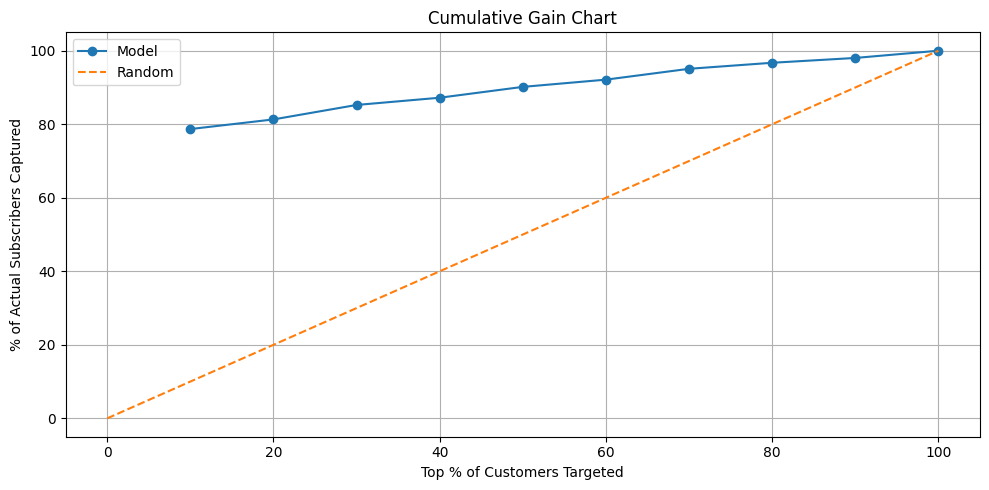

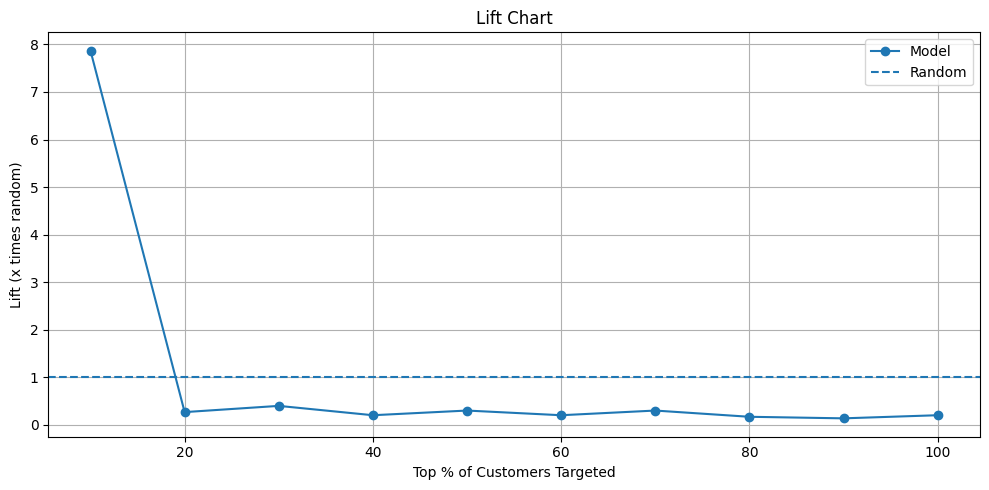

In [1]:
# gain_lift_all_in_one.py
# - 샘플 데이터(라벨/점수) 코드 생성
# - Gain/Lift 테이블 생성, 누적 이득/리프트 차트 시각화
# - matplotlib만 사용, 색상/스타일 지정 없음

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# Gain / Lift Utilities
# ============================================
def _validate_inputs(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if y_true.shape[0] != y_score.shape[0]:
        raise ValueError("y_true and y_score must have the same length.")
    if np.sum(y_true) == 0:
        raise ValueError("y_true has no positive class (sum == 0).")
    return y_true, y_score

def gain_lift_table(y_true, y_score, n_bins=10):
    """
    누적 이득/리프트 표를 반환합니다.
    Columns: bucket(1..n_bins), top_pct, positives, cum_positives, cum_gain, lift
    """
    y_true, y_score = _validate_inputs(y_true, y_score)
    df = pd.DataFrame({"y_true": y_true, "y_score": y_score}).sort_values(
        "y_score", ascending=False
    ).reset_index(drop=True)

    n = len(df)
    total_pos = df["y_true"].sum()

    # qcut 타이 이슈 회피용: 랭크 기반 등폭 버킷 (0..n_bins-1)
    ranks = np.arange(1, n + 1)
    buckets = np.minimum((np.ceil(ranks / n * n_bins) - 1).astype(int), n_bins - 1)
    df["bucket"] = buckets

    grouped = df.groupby("bucket")["y_true"].sum().reindex(range(n_bins), fill_value=0)
    cum_pos = grouped.cumsum()

    top_pct = (np.arange(1, n_bins + 1) / n_bins) * 100.0
    cum_gain = (cum_pos / total_pos) * 100.0

    expected_per_bucket = total_pos / n_bins
    with np.errstate(divide="ignore", invalid="ignore"):
        lift = np.where(expected_per_bucket > 0, grouped / expected_per_bucket, np.nan)

    return pd.DataFrame(
        {
            "bucket": np.arange(1, n_bins + 1),
            "top_pct": top_pct,
            "positives": grouped.values,
            "cum_positives": cum_pos.values,
            "cum_gain": cum_gain.values,
            "lift": lift,
        }
    )

def plot_cumulative_gain(table):
    plt.figure(figsize=(10, 5))
    plt.plot(table["top_pct"], table["cum_gain"], marker="o", label="Model")
    plt.plot([0, 100], [0, 100], linestyle="--", label="Random")
    plt.title("Cumulative Gain Chart")
    plt.xlabel("Top % of Customers Targeted")
    plt.ylabel("% of Actual Subscribers Captured")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_lift(table):
    plt.figure(figsize=(10, 5))
    plt.plot(table["top_pct"], table["lift"], marker="o", label="Model")
    plt.axhline(1.0, linestyle="--", label="Random")
    plt.title("Lift Chart")
    plt.xlabel("Top % of Customers Targeted")
    plt.ylabel("Lift (x times random)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def summarize_targets(table, coverage_list=(50, 60, 70, 80, 90)):
    """
    '가입자의 Y%를 커버하려면 상위 몇 %가 필요한가?' 요약 표 반환
    """
    out = []
    cum = table["cum_gain"].values
    tops = table["top_pct"].values
    for cov in coverage_list:
        idx = np.argmax(cum >= cov)
        if cum[idx] >= cov:
            out.append({"coverage_%": cov, "need_top_%": float(tops[idx])})
        else:
            out.append({"coverage_%": cov, "need_top_%": np.nan})
    return pd.DataFrame(out)

# ============================================
# Demo: generate sample data in code (no CSV)
# ============================================
def demo_generate_and_plot(
    n=10000,
    positive_rate=0.03,      # 실제 가입자 비율 (예: 3%)
    separation_strength=1.2, # 점수 분리 강도(클수록 양성 점수↑)
    n_bins=10
):
    rng = np.random.default_rng(42)
    y_true = rng.binomial(1, positive_rate, n)

    # 양성(1)은 평균적으로 더 높은 점수를 갖도록 분리
    base = rng.random(n)
    # separation_strength가 클수록 양성의 점수가 더 커지게 스케일링
    y_score = np.clip(base * (0.5 + separation_strength * y_true), 0, 1)

    table = gain_lift_table(y_true, y_score, n_bins=n_bins)
    print("=== Gain/Lift Table ===")
    print(table)

    print("\n=== Coverage targets (예: 50/60/70/80/90% 가입자 커버) ===")
    print(summarize_targets(table, coverage_list=(50, 60, 70, 80, 90)))

    plot_cumulative_gain(table)
    plot_lift(table)

if __name__ == "__main__":
    # 필요 시 아래 파라미터만 수정하여 실행하세요.
    demo_generate_and_plot(
        n=10000,
        positive_rate=0.03,
        separation_strength=1.2,
        n_bins=10
    )
